# Random Forest — Fake Job Posting Detection

This notebook implements the Random Forest classifier using the project's existing preprocessing pipeline.

**Project requirements**
- Target: `fraudulent`
- 80/20 train-test split
- `random_state=42`
- Stratified split
- Evaluation: Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrix, classification report
- Save model as `models/random_forest.pkl`


## 1. Project Path Setup

This cell makes the notebook work in both Google Colab and a local Jupyter environment when the repository has the standard project structure.


In [54]:
from pathlib import Path
import os

cwd = Path.cwd()

if (cwd / "dataset").exists() and (cwd / "models").exists():
    project_root = cwd
elif (cwd / "../dataset").exists() and (cwd / "../models").exists():
    project_root = cwd.parent
else:
    candidates = list(cwd.glob("*/dataset"))
    if candidates:
        project_root = candidates[0].parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. "
            "Make sure the fake-job-detection-ml-main repository is available."
        )

os.chdir(project_root / "notebooks")

print("Project root:", project_root.resolve())
print("Notebook working directory:", Path.cwd().resolve())


Project root: /content/fake-job-detection-ml-main
Notebook working directory: /content/fake-job-detection-ml-main/notebooks


## 2. Import Libraries


In [3]:
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


## 3. Load Dataset

The project uses the Fake Job Posting Prediction / EMSCAD dataset.


In [5]:
df = pd.read_csv("../dataset/fake_job_postings.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 4. Define Target and Initial Features

The project target is `fraudulent`:
- `0` = legitimate job posting
- `1` = fraudulent job posting


In [6]:
target = "fraudulent"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (17880, 17)
y shape: (17880,)


## 5. Remove `job_id`

This follows the existing preprocessing notebook.


In [7]:
X = X.drop(columns=["job_id"])

print("Dataset shape:", df.shape)
print("Feature shape after dropping job_id:", X.shape)


Dataset shape: (17880, 18)
Feature shape after dropping job_id: (17880, 16)


## 6. Define Feature Groups

These are the same feature groups used by the existing preprocessing pipeline.


In [8]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

categorical_columns = [
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

numeric_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

print("Text columns:", text_columns)
print("Categorical columns:", categorical_columns)
print("Numeric/binary columns:", numeric_columns)


Text columns: ['title', 'company_profile', 'description', 'requirements', 'benefits']
Categorical columns: ['location', 'department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
Numeric/binary columns: ['telecommuting', 'has_company_logo', 'has_questions']


## 7. Handle Missing Text Values


In [9]:
df[text_columns] = df[text_columns].fillna("")


## 8. Combine Text Columns

The existing preprocessing combines the five text fields into one text feature.


In [10]:
df["combined_text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

df["combined_text"].head()


,combined_text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


## 9. Clean Text


In [11]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["combined_text"].apply(clean_text)

df[["combined_text", "clean_text"]].head()


,combined_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


## 10. Handle Missing Categorical Values

Missing categorical values are represented as `Unknown`, matching the project's existing preprocessing.


In [12]:
df[categorical_columns] = df[categorical_columns].fillna("Unknown")

print("Missing categorical values:")
print(df[categorical_columns].isnull().sum())


Missing categorical values:
location               0
department             0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
dtype: int64


## 11. Select Final Features and Target


In [13]:
features = df[
    [
        "clean_text",
        "location",
        "department",
        "employment_type",
        "required_experience",
        "required_education",
        "industry",
        "function",
        "telecommuting",
        "has_company_logo",
        "has_questions"
    ]
]

target = df["fraudulent"]

print("Features:", features.shape)
print("Target:", target.shape)


Features: (17880, 11)
Target: (17880,)


## 12. Train/Test Split

All team models must use the same:
- 80% training / 20% testing
- `random_state=42`
- stratification by the target


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (14304, 11)
Testing: (3576, 11)


## 13. Check Target Distribution


In [15]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining target percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Training target distribution:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Testing target distribution:
fraudulent
0    3403
1     173
Name: count, dtype: int64

Training target percentage:
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64

Testing target percentage:
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64


## 14. TF-IDF Configuration

This is the same TF-IDF configuration used by the existing preprocessing notebook:
- English stop-word removal
- maximum 10,000 features
- unigram + bigram features


In [16]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)


## 15. One-Hot Encoding Configuration


In [17]:
encoder = OneHotEncoder(
    handle_unknown="ignore"
)


## 16. Build the Shared Preprocessor


In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            tfidf,
            "clean_text"
        ),
        (
            "categorical",
            encoder,
            categorical_columns
        ),
        (
            "numeric",
            "passthrough",
            numeric_columns
        )
    ]
)


## 17. Transform Training and Testing Data

The preprocessor is fitted only on the training set and then used to transform the test set.


In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)


Processed training shape: (14304, 14114)
Processed testing shape: (3576, 14114)


# Random Forest Model

## 18. Initialize Random Forest

The initial configuration uses:
- 300 trees
- `random_state=42`
- all available CPU cores
- balanced class weights because the fraudulent class is the minority class


In [21]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print(rf_model)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)


## 19. Train Random Forest


In [22]:
rf_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed.")


Random Forest training completed.


## 20. Generate Predictions


In [23]:
y_pred = rf_model.predict(X_test_processed)

# Probability of the positive class (fraudulent = 1)
y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated.")
print("First 20 predictions:", y_pred[:20])
print("First 20 fraud probabilities:", y_prob[:20])


Predictions generated.
First 20 predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
First 20 fraud probabilities: [0.05       0.00666667 0.02333333 0.00666667 0.01333333 0.00333333
 0.00666667 0.02       0.05333333 0.03       0.04333333 0.
 0.01       0.03666667 0.00666667 0.01       0.01       0.
 0.         0.00333333]


## 21. Calculate Evaluation Metrics


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("RANDOM FOREST RESULTS")
print("=" * 45)
print(f"Accuracy : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-score : {f1:.4f} ({f1 * 100:.2f}%)")
print(f"ROC-AUC  : {roc_auc:.4f} ({roc_auc * 100:.2f}%)")


RANDOM FOREST RESULTS
Accuracy : 0.9801 (98.01%)
Precision: 0.9904 (99.04%)
Recall   : 0.5954 (59.54%)
F1-score : 0.7437 (74.37%)
ROC-AUC  : 0.9925 (99.25%)


## 22. Classification Report


In [25]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3403
  Fraudulent       0.99      0.60      0.74       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



## 23. Confusion Matrix


In [26]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Values:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)


Confusion Matrix:
[[3402    1]
 [  70  103]]

Confusion Matrix Values:
True Negatives (TN): 3402
False Positives (FP): 1
False Negatives (FN): 70
True Positives (TP): 103


## 24. Plot Confusion Matrix


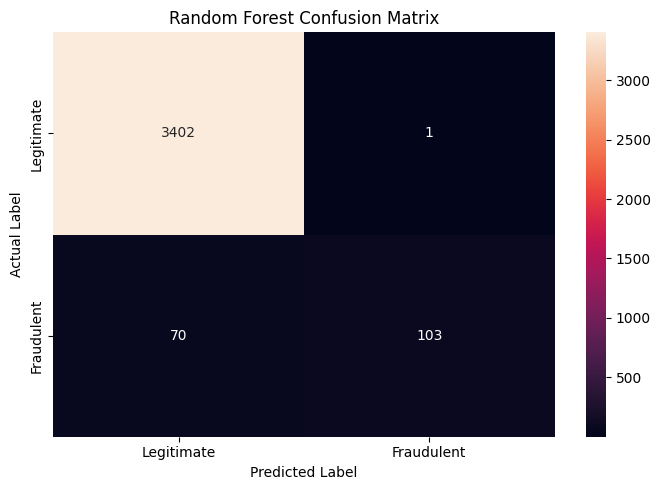

In [27]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


### 25. Final Model Configuration

This section records the important Random Forest settings used for the final model.


In [28]:
print("Final Random Forest Configuration")
print("-" * 40)
print("n_estimators :", rf_model.n_estimators)
print("random_state :", rf_model.random_state)
print("n_jobs       :", rf_model.n_jobs)
print("class_weight :", rf_model.class_weight)


Final Random Forest Configuration
----------------------------------------
n_estimators : 300
random_state : 42
n_jobs       : -1
class_weight : balanced


### 26. Save the Trained Random Forest Model

Required project path:

`models/random_forest.pkl`


In [30]:
model_path = "../models/random_forest.pkl"

joblib.dump(
    rf_model,
    model_path
)

print(f"Random Forest model saved successfully to: {model_path}")


Random Forest model saved successfully to: ../models/random_forest.pkl


## 27. Verify Saved Model


In [31]:
model_path = Path("../models/random_forest.pkl")

print("Model exists:", model_path.exists())

if model_path.exists():
    print("Model size:", round(model_path.stat().st_size / (1024 * 1024), 2), "MB")


Model exists: True
Model size: 23.64 MB


### 28. Final Results Summary

These are the values to send to the team for the final model comparison.


In [32]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Random Forest": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Random Forest (%)"] = results["Random Forest"] * 100

results


,Metric,Random Forest,Random Forest (%)
0,Accuracy,0.980145,98.014541
1,Precision,0.990385,99.038462
2,Recall,0.595376,59.537572
3,F1-score,0.743682,74.368231
4,ROC-AUC,0.992506,99.250576


# Random Forest Optimization

The baseline Random Forest achieved strong accuracy, precision, and ROC-AUC, but its recall for fraudulent job postings was lower.

This section experiments with Random Forest hyperparameters and classification thresholds to improve the balance between precision and recall.

The original test set will be kept untouched during model selection.

In [33]:
from sklearn.model_selection import train_test_split

X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training data:", X_train_rf.shape)
print("Validation data:", X_val_rf.shape)

Training data: (11443, 14114)
Validation data: (2861, 14114)


In [34]:
configs = [
    {
        "name": "RF-1",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "class_weight": "balanced"
    },
    {
        "name": "RF-2",
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_leaf": 1,
        "class_weight": "balanced"
    },
    {
        "name": "RF-3",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "class_weight": "balanced"
    },
    {
        "name": "RF-4",
        "n_estimators": 300,
        "max_depth": 30,
        "min_samples_leaf": 1,
        "class_weight": "balanced"
    },
    {
        "name": "RF-5",
        "n_estimators": 300,
        "max_depth": 30,
        "min_samples_leaf": 2,
        "class_weight": "balanced"
    },
    {
        "name": "RF-6",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "class_weight": {0: 1, 1: 2}
    },
    {
        "name": "RF-7",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "class_weight": {0: 1, 1: 3}
    }
]

print(f"Number of configurations: {len(configs)}")

Number of configurations: 7


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for config in configs:

    print(f"Training {config['name']}...")

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        class_weight=config["class_weight"],
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_rf,
        y_train_rf
    )

    val_pred = model.predict(X_val_rf)

    val_prob = model.predict_proba(
        X_val_rf
    )[:, 1]

    precision = precision_score(
        y_val_rf,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val_rf,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val_rf,
        val_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val_rf,
        val_prob
    )

    results.append({
        "Model": config["name"],
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

print("All configurations completed.")

Training RF-1...
Training RF-2...
Training RF-3...
Training RF-4...
Training RF-5...
Training RF-6...
Training RF-7...
All configurations completed.


In [36]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "F1",
    ascending=False
)

,Model,Precision,Recall,F1,ROC-AUC
5,RF-6,1.000000,0.611511,0.758929,0.987192
2,RF-3,0.933333,0.604317,0.733624,0.988759
4,RF-5,0.780488,0.690647,0.732824,0.983333
6,RF-7,1.000000,0.575540,0.730594,0.987911
3,RF-4,0.781513,0.669065,0.720930,0.983753
1,RF-2,0.987013,0.546763,0.703704,0.990198
0,RF-1,0.986842,0.539568,0.697674,0.989181


In [37]:
print(
    results_df
    .sort_values("F1", ascending=False)
    .to_string(index=False)
)

Model  Precision   Recall       F1  ROC-AUC
 RF-6   1.000000 0.611511 0.758929 0.987192
 RF-3   0.933333 0.604317 0.733624 0.988759
 RF-5   0.780488 0.690647 0.732824 0.983333
 RF-7   1.000000 0.575540 0.730594 0.987911
 RF-4   0.781513 0.669065 0.720930 0.983753
 RF-2   0.987013 0.546763 0.703704 0.990198
 RF-1   0.986842 0.539568 0.697674 0.989181


In [38]:
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight={0: 1, 1: 2},
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train_rf,
    y_train_rf
)

print("RF-6 training completed.")

RF-6 training completed.


In [39]:
val_prob = best_model.predict_proba(
    X_val_rf
)[:, 1]

print("Validation probabilities generated.")
print(val_prob[:20])

Validation probabilities generated.
[0.00666667 0.03       0.         0.91666667 0.         0.04333333
 0.06333333 0.         0.15333333 0.06       0.         0.00666667
 0.01666667 0.00333333 0.         0.         0.00666667 0.
 0.00666667 0.01666667]


In [40]:
thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds:

    val_pred_threshold = (
        val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_rf,
        val_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_val_rf,
        val_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_val_rf,
        val_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(
    threshold_df.to_string(index=False)
)

 Threshold  Precision   Recall       F1
      0.20   0.863636 0.820144 0.841328
      0.25   0.913793 0.762590 0.831373
      0.30   0.944954 0.741007 0.830645
      0.35   0.990000 0.712230 0.828452
      0.40   1.000000 0.683453 0.811966
      0.45   1.000000 0.640288 0.780702
      0.50   1.000000 0.611511 0.758929
      0.55   1.000000 0.568345 0.724771
      0.60   1.000000 0.546763 0.706977


In [41]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on validation F1:")
print(best_threshold_row)

Best threshold based on validation F1:
Threshold    0.200000
Precision    0.863636
Recall       0.820144
F1           0.841328
Name: 0, dtype: float64


In [42]:
print(threshold_df.to_string(index=False))

 Threshold  Precision   Recall       F1
      0.20   0.863636 0.820144 0.841328
      0.25   0.913793 0.762590 0.831373
      0.30   0.944954 0.741007 0.830645
      0.35   0.990000 0.712230 0.828452
      0.40   1.000000 0.683453 0.811966
      0.45   1.000000 0.640288 0.780702
      0.50   1.000000 0.611511 0.758929
      0.55   1.000000 0.568345 0.724771
      0.60   1.000000 0.546763 0.706977


Final model


In [43]:
final_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight={0: 1, 1: 2},
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(
    X_train_processed,
    y_train
)

print("Final Random Forest training completed.")

Final Random Forest training completed.


In [45]:
test_prob = final_rf_model.predict_proba(
    X_test_processed
)[:, 1]
final_rf_model.predict(X_test_processed)

array([0, 0, 0, ..., 0, 0, 0])

In [46]:
best_threshold = 0.20

test_pred = (
    test_prob >= best_threshold
).astype(int)

print("Predictions generated using threshold:", best_threshold)

Predictions generated using threshold: 0.2


In [47]:
final_accuracy = accuracy_score(
    y_test,
    test_pred
)

final_precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

print("=" * 50)
print("FINAL RANDOM FOREST TEST RESULTS")
print("=" * 50)

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {final_accuracy * 100:.2f}%")
print(f"Precision : {final_precision * 100:.2f}%")
print(f"Recall    : {final_recall * 100:.2f}%")
print(f"F1-score  : {final_f1 * 100:.2f}%")
print(f"ROC-AUC   : {final_roc_auc * 100:.2f}%")

FINAL RANDOM FOREST TEST RESULTS
Threshold : 0.20
Accuracy  : 98.91%
Precision : 91.88%
Recall    : 84.97%
F1-score  : 88.29%
ROC-AUC   : 99.42%


In [48]:
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      3403
  Fraudulent       0.92      0.85      0.88       173

    accuracy                           0.99      3576
   macro avg       0.96      0.92      0.94      3576
weighted avg       0.99      0.99      0.99      3576



In [49]:
final_cm = confusion_matrix(
    y_test,
    test_pred
)

print("Final Confusion Matrix:")
print(final_cm)

tn, fp, fn, tp = final_cm.ravel()

print("\nFinal Confusion Matrix Values:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Final Confusion Matrix:
[[3390   13]
 [  26  147]]

Final Confusion Matrix Values:
True Negatives (TN): 3390
False Positives (FP): 13
False Negatives (FN): 26
True Positives (TP): 147


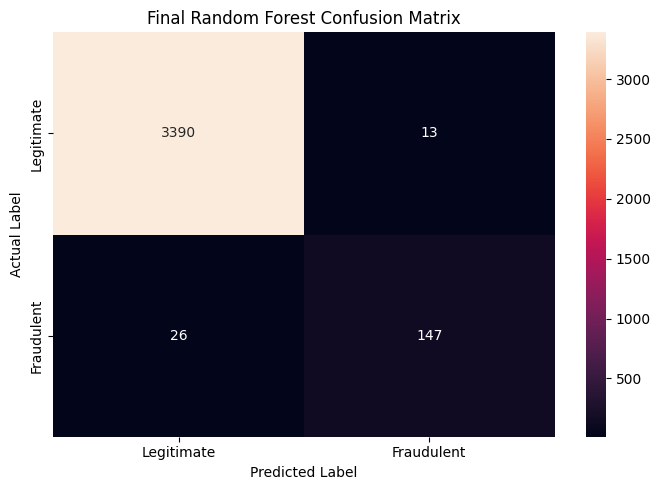

In [50]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final Random Forest Confusion Matrix")
plt.tight_layout()

plt.show()

## Final Random Forest Results

In [51]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Random Forest": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_results["Percentage"] = (
    final_results["Random Forest"] * 100
)

final_results

,Metric,Random Forest,Percentage
0,Accuracy,0.989094,98.909396
1,Precision,0.918750,91.875000
2,Recall,0.849711,84.971098
3,F1-score,0.882883,88.288288
4,ROC-AUC,0.994207,99.420691


In [52]:
from pathlib import Path
import joblib

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "random_forest.pkl"

joblib.dump(
    final_rf_model,
    model_path
)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: /content/fake-job-detection-ml-main/models/random_forest.pkl


In [53]:
print("Model exists:", model_path.exists())
print(
    "Model size:",
    round(model_path.stat().st_size / (1024 * 1024), 2),
    "MB"
)

Model exists: True
Model size: 18.06 MB


## Final Model Configuration

The final Random Forest model uses:

- Number of trees: 300
- Maximum tree depth: None
- Minimum samples per leaf: 1
- Class weights: `{0: 1, 1: 2}`
- Random state: 42
- Classification threshold: 0.20

The threshold was selected using the validation set based on the highest F1-score.
The final performance was then evaluated on the untouched test set.